In [1]:
import pandas as pd
import numpy as np
import os
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"


from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
from WMSE import WMSE, WMSE_metric

import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="0"
jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()


2025-07-31 16:23:56.806272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753975436.817861 1418227 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753975436.821314 1418227 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [3]:
from jax.lib import xla_bridge
print(xla_bridge.get_backend().platform)
jax.process_index(backend=None)

/tmp/ipykernel_1418227/4047632791.py:2: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(xla_bridge.get_backend().platform)


cpu


0

In [4]:
seed = 42

df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df') ## edit for your grid!!

df_full['logLPhot'] = np.log10(df_full['LPhot'])

df_full['lognumax'] = np.log10(df_full['numax']*3090)

df_full['logdnuSer'] = np.log10(df_full['dnuSer']*135)

df_full['logAge'] = np.log10(df_full['age'])

#### define inputs
inputs = ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe']

#### define outputs
classical_outputs = ['FeH', 'logLPhot', 'Teff']
astero_outputs = ['lognumax', 'logdnuSer'] 

outputs = classical_outputs+astero_outputs

df = df_full[inputs+outputs]

df_norm = (df - df.min())/(df.max() - df.min())
df_train = df.sample(frac=0.95, random_state=seed)
df_test = df.drop(df_train.index)
df_small = df_full.sample(1000)

In [5]:
normconsts = np.load('../grids/Chiara-normconsts-logAge.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 6

dense_layer_units = 128

Nepochs = 5000

learning_rate = 0.0001

model_name = 'logAge-logLPhot-lognumax-logdnuSer-exponent-6e-6-Adam'

loss_func = 'WMSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':model_name, 'n_dense_layers':n_dense_layers, 'dense_layer_units':dense_layer_units, 'Nepochs':Nepochs, 'lrate':learning_rate, \
        'loss':loss_func, 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'logAge', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'lognumax', 'logdnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir, 'custom_objects':{'WMSE':WMSE_metric}}

model_outputs = Emulator(emulator_kwargs, normalised = False)
model= tf.keras.models.load_model(checkpoint_dir, custom_objects = {'WMSE':WMSE_metric})

I0000 00:00:1753975445.019011 1418227 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17303 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


# Maddy's Data

In [6]:
H22 = pd.read_csv('../data/Howell_2022.txt')
H22 = H22[(H22['QF'] == 'D')&(H22['ID'].str.contains('RGB'))].reset_index()[0:10]

numax = H22['νmax'].str.split('±', expand=True)[0].astype(float)
enumax_obs = H22['νmax'].str.split('±', expand=True)[1].astype(float)
enumax_pred = 0.009*numax

enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = H22['∆ν'].str.split('±', expand=True)[0].astype(float)
ednu_obs = H22['∆ν'].str.split('±', expand=True)[1].astype(float)
ednu_pred = 0.007*dnu

ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = H22['L/L⊙'].str.split('±', expand=True)[0].astype(float)
eLPhot_obs = 0.5*np.sqrt(H22['L/L⊙'].str.split('±', expand=True)[1].astype(float)**2 + H22['L/L⊙'].str.split('±', expand=True)[2].astype(float)**2)
eLPhot_pred = 0.011*LPhot

eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)


Teff = H22['Teff'].str.split('±', expand=True)[0].astype(float)
eTeff = H22['Teff'].str.split('±', expand=True)[1].astype(float)

mask = numax > 15

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values)}
unc = {'Teff':eTeff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10)}

for key in list(obs.keys()):
    obs[key] = obs[key][mask]
    unc[key] = unc[key][mask]

num_stars = len(obs['Teff'])

# Yingxiang's Data

In [13]:
Y25 = pd.read_csv('M4_seismicanalysis_Yingxiang_Feb25.csv')
Y25 = Y25[(Y25['Quality_flag'] == 'D')&(Y25['evol_stage'] == 'RGB')&(Y25['numax_pyMon']>20)&(Y25['Delta_nu']>0)].reset_index()[1:]

numax = Y25['numax_pyMon']
enumax_obs = Y25['numax_err_pyMon']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = Y25['Delta_nu']
ednu_obs = 0.03*Y25['Delta_nu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = Y25['Lum_bol']
eLPhot_obs = np.sqrt(Y25['Lum_bol_err_random']**2 + Y25['Lum_bol_err_systematic']**2)
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = Y25['Teff_final']
eTeff = Y25['Teff_err_final']

num_stars = len(Teff)

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values), 'LPhot':LPhot.values}
unc = {'Teff':eTeff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}
unc['Teff'] = 108*np.ones_like(eTeff.values)

In [24]:
IDs

0            W491
1            W508
2      W760 ( * )
3            W779
4            W837
5           W1068
6           W1091
7           W1156
8           W1582
9           W1717
10          W1763
11          W1912
12          W2021
13    W2022 ( * )
14          W2034
15          W2162
16    W2665 ( * )
17          W2678
18    W3033 ( * )
19          W3041
20          W3073
21          W3480
22          W3528
23          W3564
24          W3742
25          W4488
Name: WID, dtype: object

# Tailo's data

In [155]:
T22 = pd.read_csv('../data/Tailo_2022_processed.csv')

remove = ['W3564', 'W2665 ( * )', 'W760 ( * )']

T22 = T22[~T22['WID'].isin(remove)].reset_index()[0:5]

IDs = T22['WID']

numax = T22['numax']
enumax_obs = T22['enumax']
enumax_pred = 0.009*numax
enumax = np.sqrt(enumax_obs**2 + enumax_pred**2)

dnu = T22['dnu']
ednu_obs = T22['ednu']
ednu_pred = 0.007*dnu
ednu = np.sqrt(ednu_obs**2 + ednu_pred**2)

LPhot = T22['LPhot']
eLPhot_obs = T22['eLPhot']
eLPhot_pred = 0.011*LPhot
eLPhot = np.sqrt(eLPhot_obs**2 + eLPhot_pred**2)

Teff = T22['Teff']

num_stars = len(Teff)

obs = {'FeH':-1.1*np.ones_like(Teff.values),  'Teff':Teff.values, 'numax':numax.values, 'dnuSer':dnu.values,'logLPhot':np.log10(LPhot.values), 'LPhot':LPhot.values}
unc = {'Teff':Teff.values, 'numax': enumax.values, 'dnuSer':ednu.values, 'FeH':0.07*np.ones_like(Teff.values), 'logLPhot':eLPhot.values/LPhot.values*1/np.log(10), 'LPhot':eLPhot.values}
unc['Teff'] = 100*np.ones_like(Teff.values)

[]

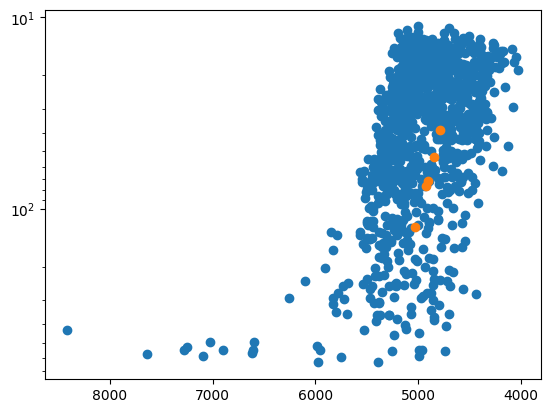

In [156]:
plt.scatter(df_small['Teff'], df_small['numax']*3090)
plt.scatter(obs['Teff'], obs['numax'])
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.semilogy()

In [167]:
T22

,index,LPhot,eLPhot,Teff,numax,enumax,dnu,ednu,WID,POPCUBI
0,0,37.865,4.083,4788.0,38.724,0.965,4.616,0.180,W491,2G
1,1,21.765,2.192,4926.0,75.929,2.367,7.613,0.231,W508,2G
2,3,28.142,3.030,4844.0,53.392,2.258,6.056,0.171,W779,1G
3,4,12.892,1.235,5030.0,123.780,3.537,11.765,0.309,W837,2G
4,5,21.934,2.229,4900.0,71.632,2.839,7.449,0.301,W1068,2G


# Fit a fake cluster - hierarchical on age

In [158]:
#@reparam(config={"age":LocScaleReparam()}) #something about this causes chaos

def shared_2param(uncs,  obs = model_outputs.obs_dict):

    mu_age = sample_beta('mu_age', 5000, 15000, alpha = 2, beta = 2)

    std_age = sample_beta('std_age', 100, 1000, alpha = 2, beta = 2)


    with numpyro.plate("star", num_stars):    

        age = numpyro.sample('age', dist.Normal(mu_age, std_age,))


#        tau = sample_beta('tau', 0.9, 0.3, alpha = 2, beta = 2)

#        massini = numpyro.deterministic ('massini', tau*(0.6426*10**4/age)**(1/3.2))

        tau = sample_beta('tau', 1.1, 0.3, alpha = 2, beta = 2)

        massini = numpyro.deterministic ('massini', tau*jnp.exp(-0.3*jnp.log(age) + 2.4))

        zini = numpyro.sample('zini', dist.TruncatedNormal(1.5*0.01756*10**-1.1, 0.3*0.01756*10**-1.1, low = 0))

        yini = numpyro.sample('yini', dist.TruncatedNormal(0.245, 0.03, low = 0.22))

        alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(1.9,0.1, low = 1.5, high = 2.3))

        eta = numpyro.sample('eta', dist.Uniform(0.001, 0.3,))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(0.4, 0.05))
               
        params = jnp.stack([massini, zini, yini, alphaMLT, jnp.log10(age), eta, alphaFe], axis = -1)

        pred = model_outputs(params)

    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.Normal(10**pred[:, 1], uncs['LPhot']), obs=obs['LPhot'])
    
    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(10**(pred[:, 3]), uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(10**(pred[:, 4]), uncs['dnuSer']), obs=obs['dnuSer'])
 





(array([ 32.,  81., 111., 135., 136., 134., 157.,  94.,  78.,  42.]),
 array([ 5028.0924565 ,  6017.57167666,  7007.05089683,  7996.530117  ,
         8986.00933717,  9975.48855734, 10964.9677775 , 11954.44699767,
        12943.92621784, 13933.40543801, 14922.88465818]),
 <BarContainer object of 10 artists>)

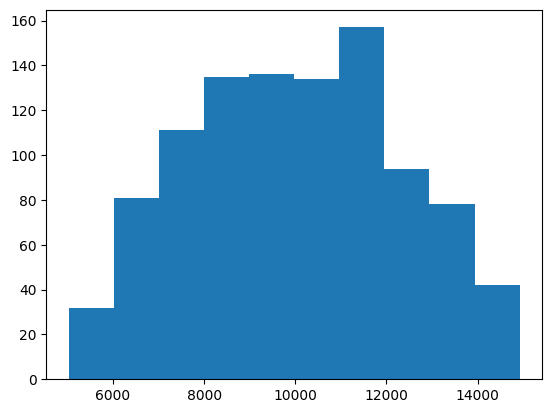

In [159]:
plt.hist(prior['mu_age'])

In [160]:
num_warmup, num_samples = 4000, 4000

num_chains = 1

sampler = NUTS(shared_2param, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_sample) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

In [161]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

num_prior_samples = 1000

prior_predictive = Predictive(shared_2param, num_samples=num_prior_samples,)

prior = prior_predictive(rng_key_, \
                         uncs=unc, )

coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

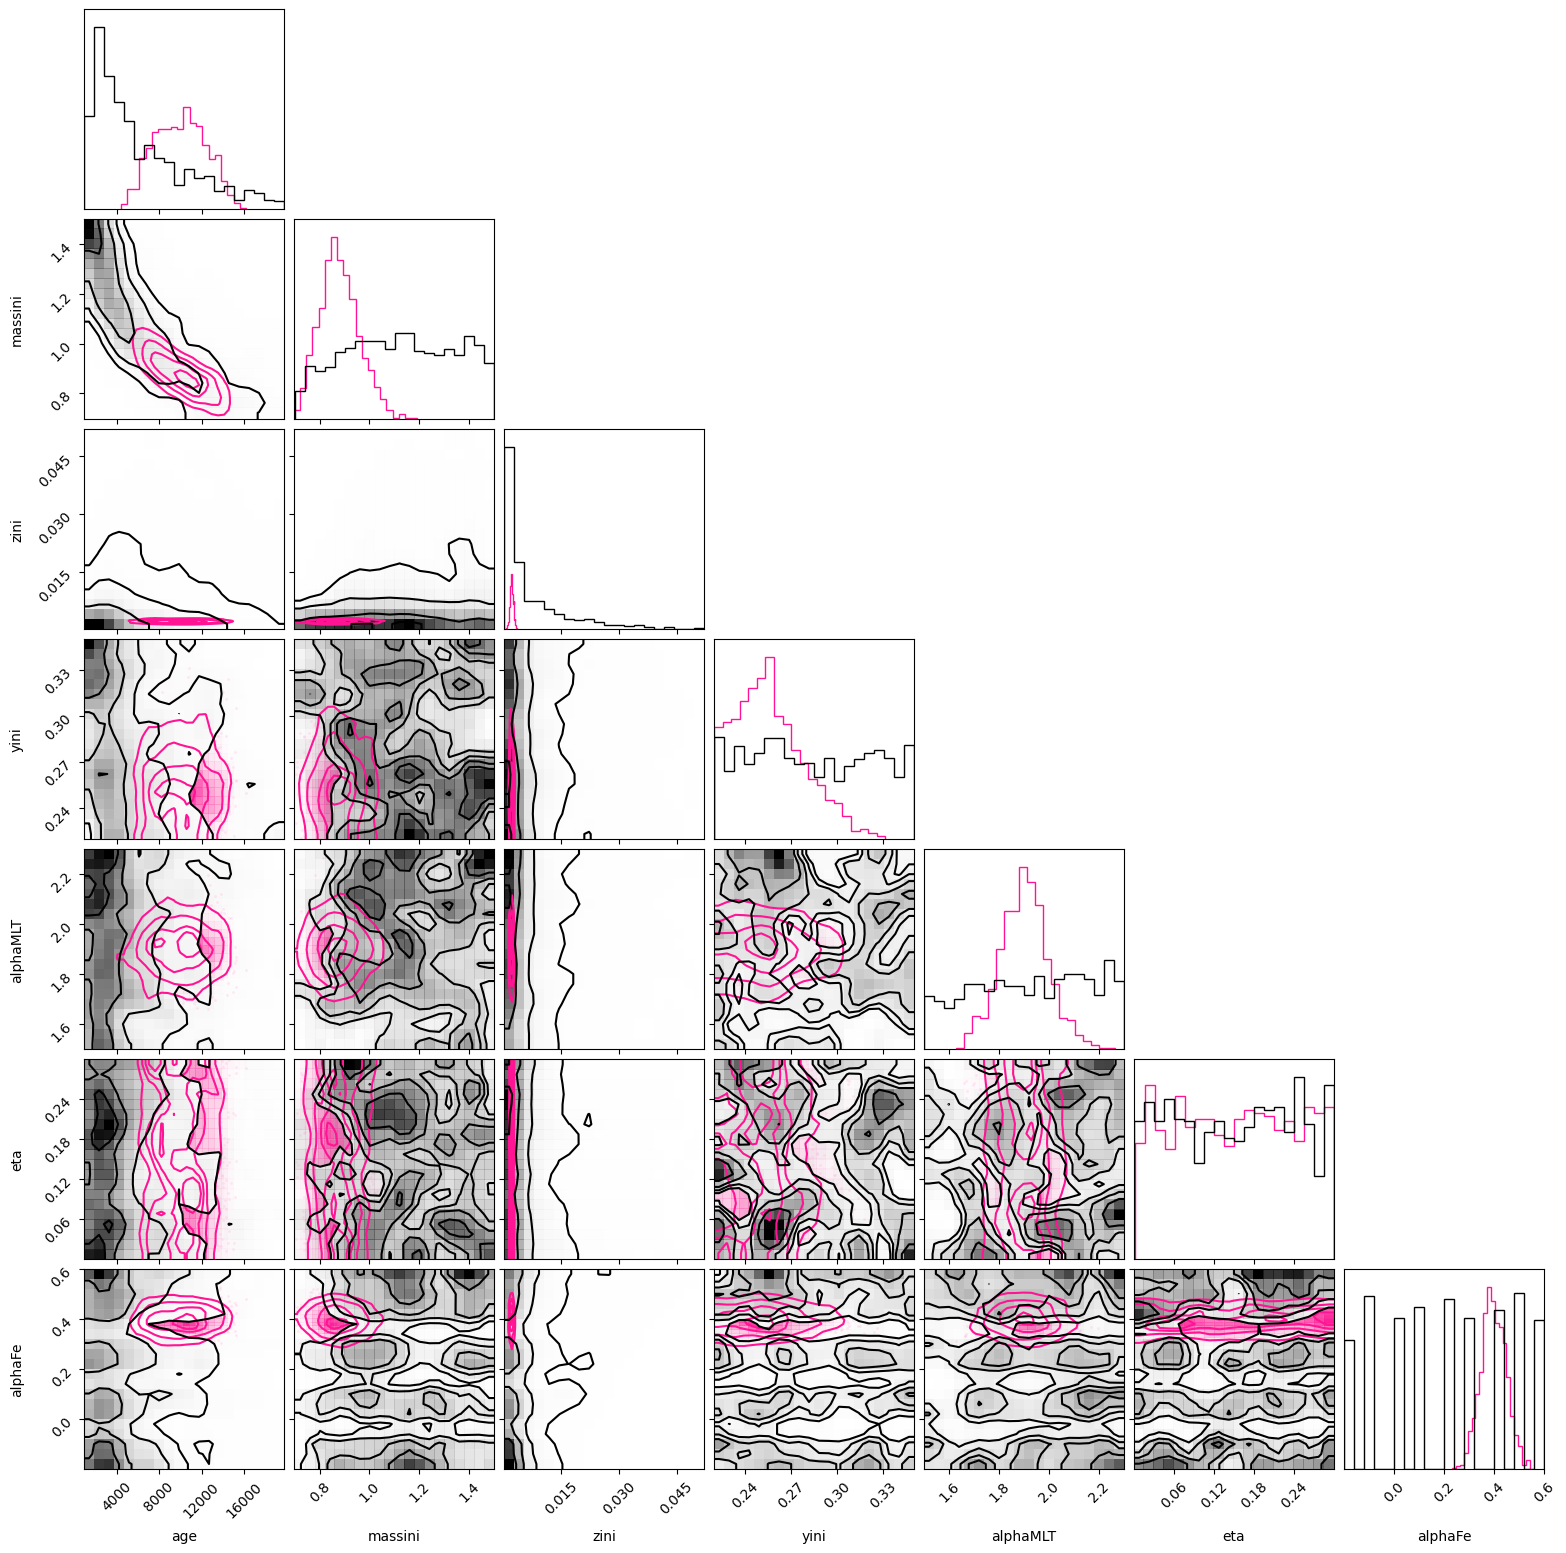

In [162]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini','zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', smooth = True, plot_datapoints = True,  weights = np.ones(num_prior_samples)/(num_prior_samples), zorder = 100, coords = {'star':0})
corner.corner(df_small[['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']],zorder = 0, alpha = 0.1, fig = fig, smooth = True, weights = np.ones_like(df_small['massini'])/len(df_small), plot_datapoints = False,)
plt.show()

In [163]:
mcmc.run(jax.random.PRNGKey(0),  uncs=unc, obs=obs)

mcmc.print_summary()

sample: 100%|█| 8000/8000 [11:10<00:00, 11.93it/s, 7 steps of size 5.14e-04. acc


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
        age[0]   7672.07      0.12   7672.04   7671.89   7672.28      3.91      1.53
        age[1]   8371.81      0.04   8371.81   8371.74   8371.88      6.63      1.14
        age[2]   9049.31      0.09   9049.32   9049.16   9049.45      3.05      2.36
        age[3]   8436.62      0.13   8436.65   8436.43   8436.79      3.05      2.75
        age[4]   9894.00      0.07   9894.01   9893.88   9894.10      4.45      1.16
    alphaFe[0]      0.38      0.00      0.38      0.38      0.38      2.82      2.87
    alphaFe[1]      0.33      0.00      0.33      0.33      0.33      3.72      1.92
    alphaFe[2]      0.49      0.00      0.49      0.49      0.49      4.57      1.66
    alphaFe[3]      0.35      0.00      0.35      0.35      0.35      3.43      2.32
    alphaFe[4]      0.35      0.00      0.35      0.35      0.35      3.72      1.94
   alphaMLT[0]      1.73      0.00      1.73      1.72      1.73

NameError: name 'Y25' is not defined

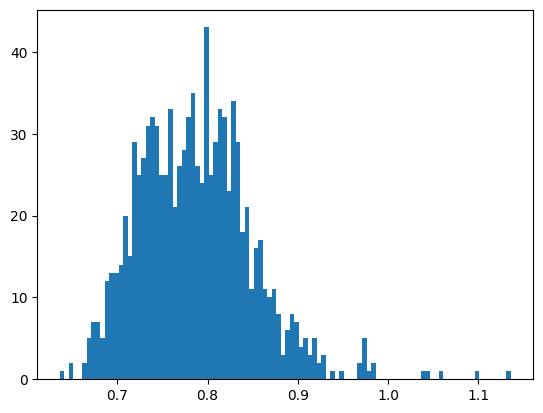

In [75]:
plt.hist(prior['massini'].T[3], bins = 100)
for i in Y25['Mass'].values:
    plt.axvline(i, color = 'black', linestyle = '--')

In [164]:
posterior = mcmc.get_samples(group_by_chain=True)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))

posterior_predictive = Predictive(shared_2param, posterior_samples=posterior, parallel=True, batch_ndims=2)

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)

In [79]:
obs['numax'][12]

np.float64(62.18183685)

In [80]:
Y25

,index,star_id,evol_stage,Gaia_source_ID_DR3,2MASS_ID,Gmag,Quality_flag,numax_pyMon,numax_err_pyMon,Teff_final,Teff_err_final,Lum_bol,Lum_bol_err_random,Lum_bol_err_systematic,Mass,Mass_err_rand,Delta_nu,delta_nu_02,epsilon
1,13,M4RGB188,RGB,6.050000e+18,16232169-2626468,13.04,D,30.981079,0.568750,4810,108.001212,44.00,1.53,5.11,0.84,0.07,3.75,NaN,0.600
2,15,M4RGB104,RGB,6.050000e+18,16232195-2630320,13.13,D,33.730326,0.568750,4851,108.001212,38.85,1.28,4.51,0.78,0.06,4.32,0.130,0.926
3,16,M4RGB17,RGB,6.050000e+18,16232252-2629422,13.54,D,51.888145,0.710937,4785,61.000000,28.35,0.60,3.29,0.92,0.05,5.84,0.170,1.230
4,22,M4RGB13,RGB,6.050000e+18,16232508-2629530,13.52,D,49.202833,1.990624,4840,108.001212,26.95,0.90,3.12,0.79,0.07,6.39,0.120,1.290
5,32,M4RGB23,RGB,6.050000e+18,16233236-2629222,13.36,D,42.553491,1.042708,4897,108.001212,31.25,0.97,3.62,0.77,0.06,5.39,0.130,1.080
6,35,M4RGB37,RGB,6.050000e+18,16233380-2627497,13.14,D,35.136918,0.663541,4821,108.001212,39.61,1.35,4.60,0.85,0.07,4.86,0.170,0.890
7,36,M4RGB129,RGB,6.050000e+18,16233414-2630104,13.76,D,70.173835,1.990624,4989,108.001212,22.63,0.62,2.63,0.86,0.07,7.35,0.130,1.240
8,44,M4RGB252,RGB,6.050000e+18,16233768-2620381,13.57,D,55.276752,0.663541,5012,60.000000,26.65,0.41,3.09,0.78,0.04,5.84,0.130,1.050
9,50,M4RGB244,RGB,6.050000e+18,16233893-2622094,13.04,D,32.131927,0.189583,4877,62.000000,44.15,0.84,5.12,0.83,0.04,3.71,0.180,0.580
10,52,M4RGB130,RGB,6.050000e+18,16234091-2630093,13.07,D,36.927124,0.568750,4897,108.001212,40.16,1.24,4.65,0.85,0.07,4.29,0.129,0.970


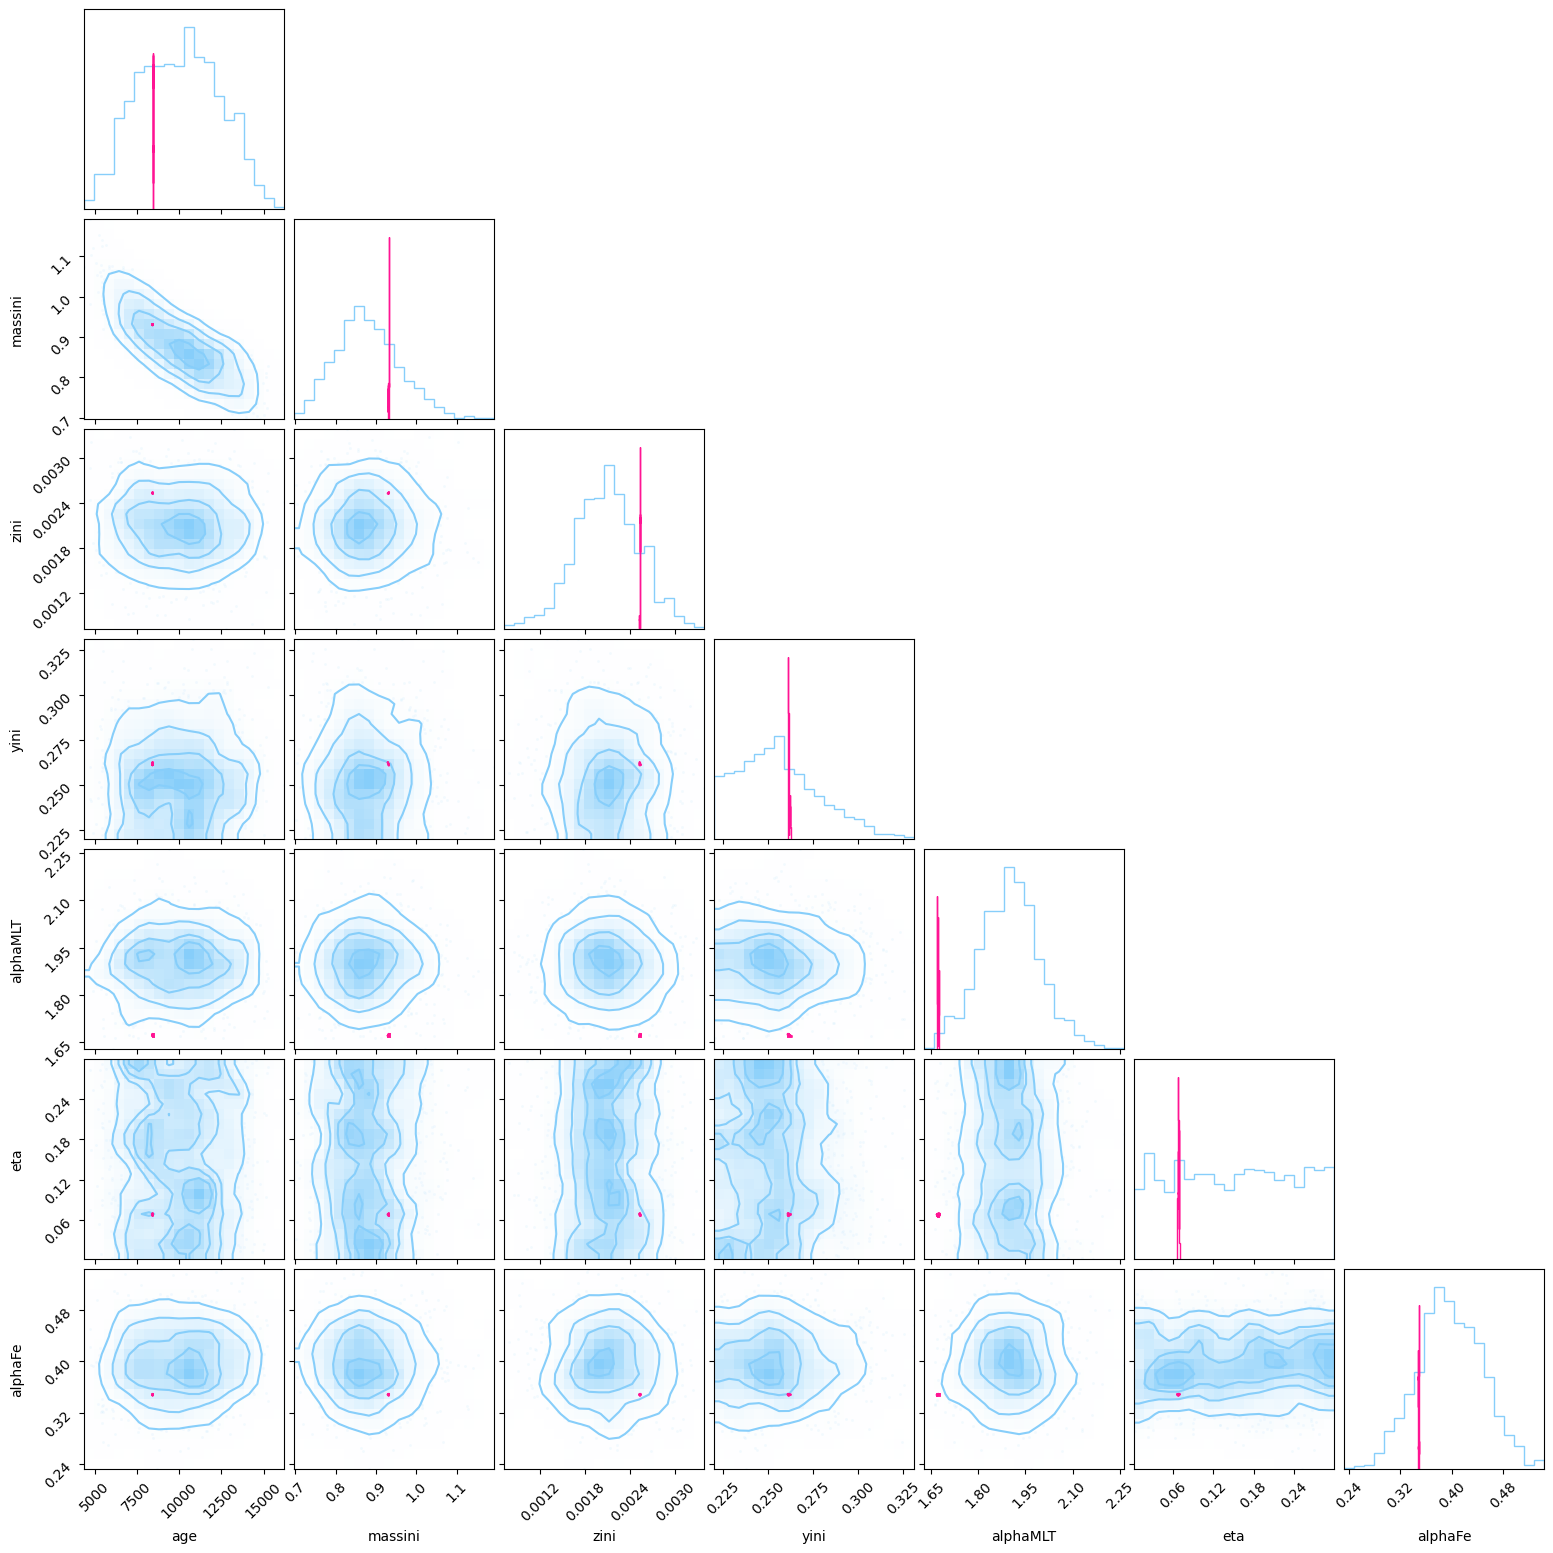

In [165]:
fig = corner.corner(data, group="prior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'lightskyblue', smooth = True, plot_datapoints = True, weights = np.ones(num_prior_samples)/(num_prior_samples), coords = {'star':0})
corner.corner(data, group="posterior", var_names = ['age', 'massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe'],  color = 'deeppink', zorder = 1,smooth = True, plot_datapoints = True, weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),fig = fig, coords = {'star':3})
#fig.savefig(f'./hierarchical-yini-zini-age-corner-massfromage.png', bbox_inches = 'tight', dpi = 150)
plt.show()


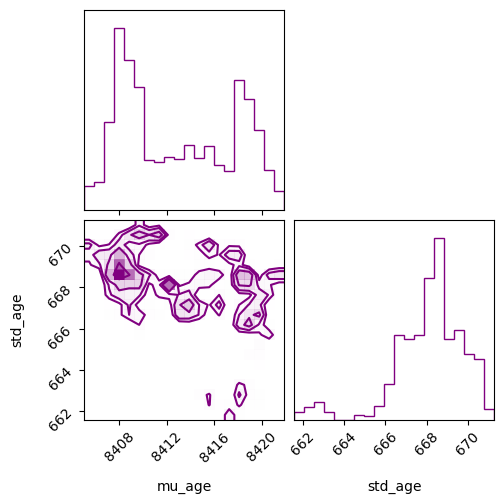

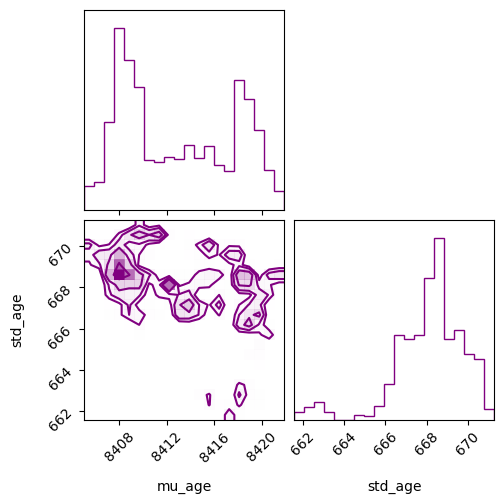

In [166]:
corner.corner(data, group="posterior", var_names = ['mu_age', 'std_age', ], color = 'purple', plot_datapoints = False,  weights = np.ones(num_chains*num_samples)/(num_chains*num_samples),)

In [59]:
np.mean(posterior['std_yini'].T[0])

Array(0.00137752, dtype=float64)